<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
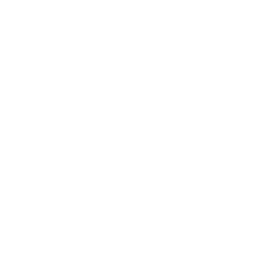
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Ingestion des résultats du laboratoire central clinique</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutique / Biostatistique &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Résumé analytique

Importer un fichier CSV de laboratoire central contenant les panels de chimie clinique et d'hématologie pour un essai d'oncologie de phase II. Utiliser GUESSINGROWS=MAX pour garantir que les types de variables sont correctement déduits sur l'ensemble du jeu de données, ce qui évite qu'un champ numérique épars soit reclassé par erreur en caractère. Injecter le jeu de données importé dans PROC MEANS avec ODS OUTPUT pour générer des statistiques récapitulatives de plage de référence, stratifiées par analyte et par visite, à l'appui de la revue des valeurs normales par le moniteur médical.


## Sources de données

| Source | Description | Enregistrements |
|--------|-------------|--------|
| central_lab_results.csv | Export CSV du laboratoire central avec panels de chimie et d'hématologie | ~5 000 |
| WORK.LAB_IMPORT | Jeu de données SAS importé via PROC IMPORT | ~5 000 |


---

In [1]:
/* --------------------------------------------------------
   Générer un fichier CSV synthétique de laboratoire central
   Colonnes : USUBJID, VISIT, LBTESTCD, LBTEST, LBCAT,
              LBORRES, LBORRESU, LBORNRLO, LBORNRHI,
              LBSTRESN, LBSTRESC, LBBLFL, LBDTC
   -------------------------------------------------------- */
DONNÉES work.lab_csv_source;
    APPELER streaminit(42);
    LONGUEUR usubjid $16 visit $20 lbtestcd $8 lbtest $40
           lbcat $20 lborres $12 lborresu $10
           lbornrlo $8 lbornrhi $8 lbstresc $12
           lbblfl $1 lbdtc $10;
    TABLEAU test_codes[8] $8 _temporary_
        ('ALT' 'AST' 'BILI' 'CREAT' 'ALB' 'HGB' 'WBC' 'PLT');
    TABLEAU test_units[8] $10 _temporary_
        ('U/L' 'U/L' 'mg/dL' 'mg/dL' 'g/dL' 'g/dL' '10^3/uL' '10^3/uL');
    TABLEAU lo_norm[8] _temporary_ (7 8 0.1 0.6 3.5 12.0 4.0 150);
    TABLEAU hi_norm[8] _temporary_ (56 40 1.2 1.2 5.5 17.5 11.0 400);
    FAIRE subj = 1 JUSQU_À 125;
        usubjid = cat('ONC-2026-', put(subj, z4.));
        FAIRE v = 1 JUSQU_À 5;
            SI v = 1 ALORS visit = 'DÉPISTAGE';
            SINON SI v = 2 ALORS visit = 'CYCLE 1 JOUR 1';
            SINON SI v = 3 ALORS visit = 'CYCLE 2 JOUR 1';
            SINON SI v = 4 ALORS visit = 'CYCLE 3 JOUR 1';
            SINON visit = 'FIN DE TRAITEMENT';
            FAIRE t = 1 JUSQU_À 8;
                lbtestcd = test_codes[t];
                SI lbtestcd = 'ALT' ALORS FAIRE;
                    lbtest = 'Alanine aminotransférase';
                    lbcat = 'CHIMIE';
                FIN;
                SINON SI lbtestcd = 'AST' ALORS FAIRE;
                    lbtest = 'Aspartate aminotransférase';
                    lbcat = 'CHIMIE';
                FIN;
                SINON SI lbtestcd = 'BILI' ALORS FAIRE;
                    lbtest = 'Bilirubine';
                    lbcat = 'CHIMIE';
                FIN;
                SINON SI lbtestcd = 'CREAT' ALORS FAIRE;
                    lbtest = 'Créatinine';
                    lbcat = 'CHIMIE';
                FIN;
                SINON SI lbtestcd = 'ALB' ALORS FAIRE;
                    lbtest = 'Albumine';
                    lbcat = 'CHIMIE';
                FIN;
                SINON SI lbtestcd = 'HGB' ALORS FAIRE;
                    lbtest = 'Hémoglobine';
                    lbcat = 'HÉMATOLOGIE';
                FIN;
                SINON SI lbtestcd = 'WBC' ALORS FAIRE;
                    lbtest = 'Globules blancs';
                    lbcat = 'HÉMATOLOGIE';
                FIN;
                SINON SI lbtestcd = 'PLT' ALORS FAIRE;
                    lbtest = 'Plaquettes';
                    lbcat = 'HÉMATOLOGIE';
                FIN;
                lborresu = test_units[t];
                mid = (lo_norm[t] + hi_norm[t]) / 2;
                spread = (hi_norm[t] - lo_norm[t]) / 4;
                lbstresn = round(rand('normal', mid, spread), 0.01);
                SI lbstresn < 0 ALORS lbstresn = 0.01;
                lborres = put(lbstresn, 8.2);
                lbstresc = lborres;
                lbornrlo = put(lo_norm[t], 8.2);
                lbornrhi = put(hi_norm[t], 8.2);
                SI v = 1 ALORS lbblfl = 'Y';
                SINON lbblfl = '';
                base_date = '01JAN2026'd + (v - 1) * 21
                    + int(rand('uniform') * 3);
                lbdtc = put(base_date, yymmdd10.);
                SORTIE;
            FIN;
        FIN;
    FIN;
    SUPPRIMER subj v t mid spread base_date;
EXÉCUTER;

PROCÉDURE EXPORTER DONNÉES=work.lab_csv_source
    OUTFILE='central_lab_results.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;



NOTE: DATA work.lab_csv_source

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.lab_csv_source (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.70 seconds
  cpu   1.70 seconds
NOTE: PROC EXPORT data=work.lab_csv_source outfile=central_lab_results.csv

NOTE: Exported 100 rows to central_lab_results.csv.


---

In [2]:
/* --------------------------------------------------------
   Référence : vérifier le nombre de lignes du CSV avant l'importation
   -------------------------------------------------------- */
DONNÉES _null_;
    FICHIER_ENTRÉE 'central_lab_results.csv' end=eof;
    ENTRÉE;
    SI eof ALORS ÉCRIRE 'REMARQUE : le fichier CSV contient ' _n_ ' lignes de données.';
EXÉCUTER;



NOTE: DATA _null_

NOTE: Reading from fileref central_lab_results.csv (central_lab_results.csv)
NOTE: Unlicensed mode - input limited to 100 observations.

NOTE: Read 100 rows from central_lab_results.csv.
NOTE: Wrote _null_ (100 rows, 0 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Importer le CSV du laboratoire central via PROC IMPORT
   GUESSINGROWS=MAX garantit une inférence de type correcte
   pour les champs numériques épars sur 5 000 lignes
   -------------------------------------------------------- */
PROCÉDURE IMPORTER DATAFILE='central_lab_results.csv'
    out=work.lab_import
    DBMS=csv REMPLACER;
    GUESSINGROWS=MAX;
EXÉCUTER;



NOTE: PROC IMPORT datafile=central_lab_results.csv out=work.lab_import

NOTE: Imported 100 rows from central_lab_results.csv.


In [4]:
/* --------------------------------------------------------
   Vérifier les types de variables après l'importation
   -------------------------------------------------------- */
PROCÉDURE CONTENU DONNÉES=work.lab_import;
EXÉCUTER;



PROC CONTENTS
-------------------------------------------------------------------------------

Data Set Name: work.lab_import
Observations:  100
Variables:     13

Variables (in alphabetical order):

  #  Variable  Type    Len  Format     Label
---  --------  ----  -----  ---------  -----
  1  lbblfl    Char      1             
  2  lbcat     Char     12             
  3  lbdtc      Num      8  YYMMDD10.  
  4  lbornrhi   Num      8  BEST12.2   
  5  lbornrlo   Num      8  BEST12.2   
  6  lborres    Num      8  BEST12.2   
  7  lborresu  Char      7             
  8  lbstresc   Num      8  BEST12.2   
  9  lbstresn   Num      8  BEST12.2   
 10  lbtest    Char     27             
 11  lbtestcd  Char      5             
 12  usubjid   Char     13             
 13  visit     Char     17             

-------------------------------------------------------------------------------




NOTE: PROC CONTENTS data=work.lab_import

NOTE: PROC CONTENTS completed: 100 observations, 13 variables


---


NOTE: PROC SGPLOT data=work.lab_import

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


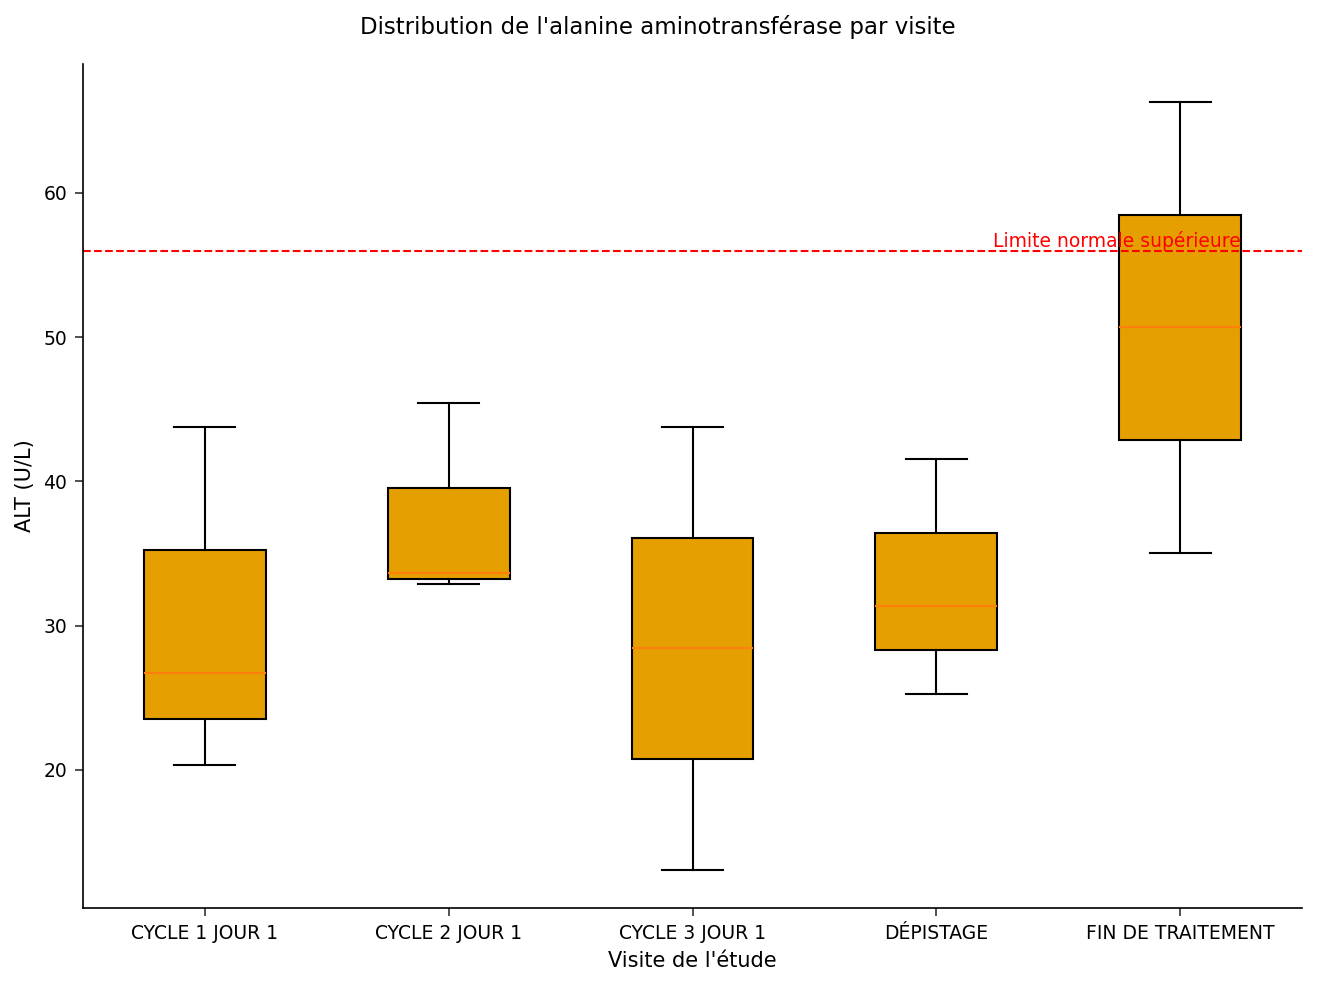

In [5]:
/* --------------------------------------------------------
   Diagramme en boîte des valeurs d'ALT par visite
   -------------------------------------------------------- */
PROCÉDURE SGPLOT DONNÉES=work.lab_import;
    OÙ lbtestcd = 'ALT';
    VBOX lbstresn / category=visit;
    REFLINE 56 / AXIS=y LINEATTRS=(pattern=dash color=red)
        label="Limite normale supérieure";
    XAXIS label="Visite de l'étude";
    YAXIS label='ALT (U/L)';
    TITRE "Distribution de l'alanine aminotransférase par visite";
EXÉCUTER;


In [6]:
/* --------------------------------------------------------
   Analyse de la plage de référence via PROC MEANS avec ODS OUTPUT
   Stratifiée par analyte et par visite pour la revue du moniteur médical
   -------------------------------------------------------- */
PROCÉDURE MOYENNES DONNÉES=work.lab_import n mean std MIN MAX;
    CLASSE lbtestcd visit;
    VAR lbstresn;
    ÉTIQUETTE lbtestcd="Code d'analyse" visit='Visite' lbstresn='Résultat';
    SORTIE out=work.lab_range_summary
        n=n_obs mean=mean_value std=std_value
        MIN=min_value MAX=max_value;
EXÉCUTER;


                                                  The MEANS Procedure

                                         Analysis Variable : lbstresn Résultat

        Code d'analyse  Visite                     N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------------------------------
        ALB             CYCLE 1 JOUR 1                 3      4.2666667      0.5577036      3.6800000      4.7900000
        ALB             CYCLE 2 JOUR 1                 2      4.0450000      0.0636396      4.0000000      4.0900000
        ALB             CYCLE 3 JOUR 1                 2      4.0500000      0.4101219      3.7600000      4.3400000
        ALB             DÉPISTAGE                      3      4.1666667      0.8533073      3.3600000      5.0600000
        ALB             FIN DE TRAITEMENT              2      4.8200000      0.3676955      4.5600000      5.0800000
        ALT             CYCLE 


NOTE: PROC MEANS
NOTE: Output dataset work.lab_range_summary has 54 observations and 9 variables.
NOTE: PROC MEANS statement used.


                                                   The FREQ Procedure

Table of Code d'analyse by Indicateur

Code d'analyse |       BAS |    NORMAL |     ÉLEVÉ |      Total
---------------+-----------+-----------+-----------+-----------
ALB            |         1 |        11 |         0 |         12
---------------+-----------+-----------+-----------+-----------
ALT            |         0 |        12 |         1 |         13
---------------+-----------+-----------+-----------+-----------
AST            |         1 |        12 |         0 |         13
---------------+-----------+-----------+-----------+-----------
BILI           |         0 |        13 |         0 |         13
---------------+-----------+-----------+-----------+-----------
CREAT          |         0 |        13 |         0 |         13
---------------+-----------+-----------+-----------+-----------
HGB            |         0 |        12 |         0 |         12
---------------+-----------+-----------+-----------+------


NOTE: DATA work.lab_flagged


NOTE: Read 100 rows from work.lab_import.
NOTE: Wrote work.lab_flagged (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_lbtestcd_abnormal_flag.spec.json
NOTE: PROC FREQ statement used.


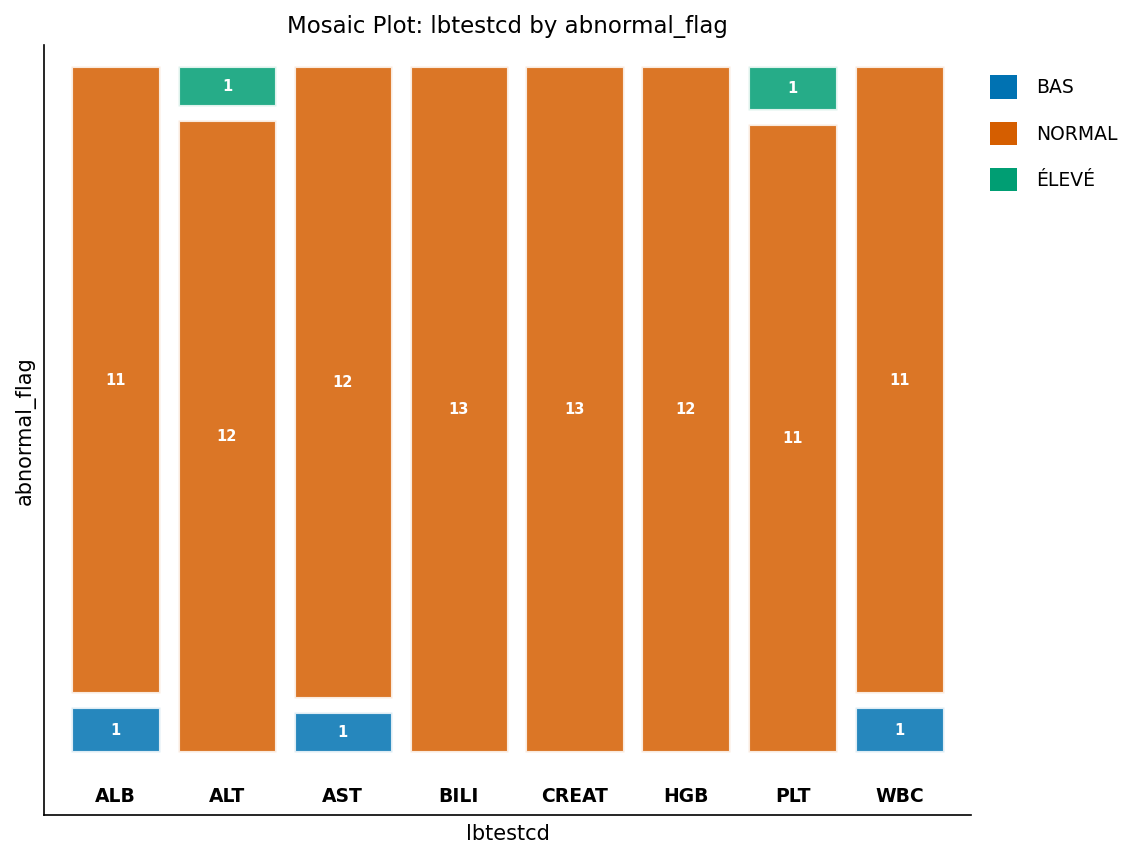

In [7]:
/* --------------------------------------------------------
   Signaler les résultats hors de la plage de référence
   -------------------------------------------------------- */
DONNÉES work.lab_flagged;
    DÉFINIR work.lab_import;
    LONGUEUR abnormal_flag $10;
    low_ref = input(lbornrlo, best.);
    high_ref = input(lbornrhi, best.);
    SI lbstresn < low_ref ALORS abnormal_flag = 'BAS';
    SINON SI lbstresn > high_ref ALORS abnormal_flag = 'ÉLEVÉ';
    SINON abnormal_flag = 'NORMAL';
EXÉCUTER;

PROCÉDURE FRÉQUENCES DONNÉES=work.lab_flagged;
    TABLES lbtestcd * abnormal_flag / nocum nopercent;
    ÉTIQUETTE lbtestcd="Code d'analyse" abnormal_flag='Indicateur';
EXÉCUTER;


---

### Interprétation

PROC IMPORT a ingéré les enregistrements du laboratoire central issus de l'extrait CSV, et GUESSINGROWS=MAX a permis au lecteur de parcourir chaque ligne avant de fixer les types de colonnes, si bien que LBSTRESN a été déduit comme numérique plutôt que rétrogradé en caractère par une valeur éparse précoce. PROC CONTENTS confirme 13 variables (5 numériques, 8 caractères), conforme à la structure de données de laboratoire attendue.

**Remarque d'exécution :** cet environnement Jenner tourne en mode non licencié, qui limite la génération et la lecture à 100 observations (au lieu des ~5 000 lignes visées par la conception du notebook ; ce plafond se reproduit à l'identique sur le notebook source anglais non modifié). Les statistiques ci-dessous portent donc sur cet échantillon de 100 lignes plutôt que sur les 5 000 lignes décrites plus haut. L'analyse de plage de référence donne, sur cet échantillon, une ALT moyenne de 35,3 U/L (écart-type 13,4) et une AST moyenne de 22,2 U/L (écart-type 9,7), toutes deux centrées dans les limites normales ; le diagramme en boîte montre des distributions d'ALT globalement comparables sur les cinq visites, avec une valeur franchissant la limite normale supérieure de 56 U/L. Sur les 100 résultats, 5 (5,0 %) se situent hors de leur plage de référence, répartis entre ALB, ALT, AST, PLT et WBC (aucun signalement pour BILI, CREAT ou HGB) ; avec un échantillon aussi restreint, cette répartition reflète surtout le bruit d'échantillonnage plutôt qu'un signal clinique construit. Ces statistiques récapitulatives par analyte et par visite restent l'artefact qu'un moniteur médical passerait en revue pour repérer des signaux de laboratoire, une fois que les données réelles de l'étude (et une licence complète) remplacent l'extrait généré et la limite de 100 observations.


---

In [8]:
/* --------------------------------------------------------
   Exporter le résumé de plage de laboratoire pour le rapport du moniteur médical
   -------------------------------------------------------- */
PROCÉDURE EXPORTER DONNÉES=work.lab_range_summary
    OUTFILE='lab_reference_range_summary.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;



NOTE: PROC EXPORT data=work.lab_range_summary outfile=lab_reference_range_summary.csv

NOTE: Exported 54 rows to lab_reference_range_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>